In [48]:
from __future__ import annotations
import torch
import torch.nn as nn

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
%matplotlib inline

np.random.seed(42)
torch.manual_seed(0)

# Question 1:
Implement and train an MLP as
specified in the assignment using PyTorch and multi-class cross entropy as the cost function. Experiment with
each of the four datasets to find the best number of nodes k from {2, 3, 5, 7, 9} in the hidden layer.

### Define network + dataloader

In [49]:
from dataclasses import dataclass
from typing import Any, Literal
import pathlib

from torch.utils.data import Dataset, DataLoader
import pandas as pd

# NETWORK DEFINITION
class ConorNet(nn.Module):
    """
    1xk neural network for HW1

    Here is a good clear reference for good nn code:
    https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
    """

    @dataclass(eq=True, order=True, unsafe_hash=True)
    class Hyperparams:
        """Hyperparameters for training + model"""
        k: int = 7
        """Number of nodes in the hidden layer. One of {2, 3, 5, 7, 9}"""

        activation: str | Literal["tanh", "relu", "sigmoid", "leaky"] = "tanh"
        learning_rate: float = 1E-3
        training_epochs: int = 5
        batch_size: int = 50

    def __init__(self, p: Hyperparams, use_softmax: bool = True):
        super().__init__()
        match p.activation:
            case "tanh":
                self._act = nn.Tanh()
            case "relu":
                self._act = nn.ReLU()
            case "sigmoid":
                self._act = nn.Sigmoid()
            case "leaky":
                self._act = nn.LeakyReLU()
            case _:
                raise NotImplementedError("Unrecognized activation function.")

        self.hparams = p

        # our network performs binary classification on an R2 input space, predicting 0 or 1.
        self._net = nn.Sequential(
            nn.Linear(2, self.hparams.k, bias=True),
            self._act,
            nn.Linear(self.hparams.k, 2, bias=True)
        )
        self._output = nn.Softmax(dim=1) if use_softmax else nn.Sigmoid()

    def forward(self, x):
        logits = self._net(x)
        return self._output(logits)
    
# DATALOADERS
class HW1Dataset(Dataset):
    """Dataset representation for the given CSV files

    they all have the same columns etc.
    """
    def __init__(self, csv_file: pathlib.Path) -> None:
        self.data = pd.read_csv(csv_file, header=0)

        # sanity check
        if list(self.data.columns) != ["label", "x1", "x2"]:
            raise ValueError(f"Incorrect column names {self.data.columns}")

        self.X = self.data[["x1", "x2"]].to_numpy(dtype=np.float32)
        self.y = self.data["label"].to_numpy(dtype=np.int64)
    
    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index) -> tuple[torch.Tensor, torch.Tensor]:
        return torch.tensor(self.X[index]), torch.tensor(self.y[index])

DSET_ROOT = pathlib.Path.cwd()
"""
Dataset root directory.

Sticking with the convention in the assignment zip, which is a flat directory with data + code.
"""

def smoke_test() -> None:
    # perform an initial evaluation, just to smoke test the code above.
    # doing this in function scope to not pollute the global namespace
    # i hate messy jupyter notebooks lol
    dset_path = DSET_ROOT / "spiral_train.csv"
    p = ConorNet.Hyperparams()

    train_dset = HW1Dataset(dset_path)
    train_dloader = DataLoader(train_dset, batch_size=p.batch_size, shuffle=True)

    print(f"Dataset: {dset_path}")
    print(f"len={len(train_dloader)}")
    xbatch, ybatch = next(iter(train_dloader))
    print(f"feature batch shape: {xbatch.size()}")
    print(f"label batch shape: {ybatch.size()}")
    print(f"idx 0--feat: {xbatch[0]}, label: {ybatch[0]}")

    print("\nEvaluating model...")
    model = ConorNet(p)
    # eval the model on the first batch we get
    logits: torch.Tensor = model(xbatch)
    print("logits: ")
    print(logits)

    # take argmax to get our yhat (since output node 0 = 0, output node 1 = 1)
    yhat = logits.argmax(dim=1)
    print("yhat:")
    print(yhat)

smoke_test()

Dataset: /home/conor/Documents/W2026/demeter_msai437/hw1/spiral_train.csv
len=4
feature batch shape: torch.Size([50, 2])
label batch shape: torch.Size([50])
idx 0--feat: tensor([-2.1221, -5.6075]), label: 1

Evaluating model...
logits: 
tensor([[0.3108, 0.6892],
        [0.5743, 0.4257],
        [0.3254, 0.6746],
        [0.6774, 0.3226],
        [0.6813, 0.3187],
        [0.6739, 0.3261],
        [0.4021, 0.5979],
        [0.6110, 0.3890],
        [0.6802, 0.3198],
        [0.6862, 0.3138],
        [0.3081, 0.6919],
        [0.6234, 0.3766],
        [0.4742, 0.5258],
        [0.3200, 0.6800],
        [0.4086, 0.5914],
        [0.6817, 0.3183],
        [0.6222, 0.3778],
        [0.6006, 0.3994],
        [0.6506, 0.3494],
        [0.4523, 0.5477],
        [0.6215, 0.3785],
        [0.6171, 0.3829],
        [0.6232, 0.3768],
        [0.6445, 0.3555],
        [0.3734, 0.6266],
        [0.6960, 0.3040],
        [0.2975, 0.7025],
        [0.6800, 0.3200],
        [0.3766, 0.6234],
        [

### Create Testing & Plotting Functions
Let's make my life easier by mostly automating:
- hyperparameter search (exhaustively over k, hand-wavily over other params)
- helpful debug plots for the hyperparam search
- plots & reports for the best set of hparams as required in the assignment

My general strategy will be to try to optimize the hyperparams other than k at k=5 for the two gaussians test, 
because I have a vague sense that'll be a pretty decent value with enough training epochs.

Then, once I have sane values for the other params, I'll try out all k values.

In [50]:
# first, some one-time setup stuff

# load all the datasets into a convenient map
def load_datasets() -> dict[str, dict[str, HW1Dataset]]:
    """Load all the datasets into a convenient map."""
    names = ["center_surround", "spiral", "two_gaussians", "xor"]
    types = ["test", "train", "valid"]

    dsets = dict()
    count = 0
    for name in names:
        dsets[name] = dict()
        for t_ in types:
            path = DSET_ROOT / f"{name}_{t_}.csv"
            dsets[name][t_] = HW1Dataset(path)
            count += 1
    
    print(f"loaded {count} datasets.")
    return dsets

DSETS = load_datasets()

loaded 12 datasets.


In [61]:
from itertools import product
from typing import Iterable

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

############
# train_loop() and test_loop() are from an example in the pytorch docs:
# (https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html#full-implementation).

def train_loop(dataloader, model, loss_fn, optimizer, p: ConorNet.Hyperparams, debug_print=False) -> float:
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    model.to(DEVICE)
    loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(DEVICE)
        y = y.to(DEVICE)

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0 and debug_print:
            loss, current = loss.item(), batch * p.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    return loss.item() # type: ignore


def test_loop(dataloader, model, loss_fn, p: ConorNet.Hyperparams, debug_print=False) -> tuple[float, float]:
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        model.to(DEVICE)
        for X, y in dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    if debug_print:
        print(f"Test Performance - Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    return correct, test_loss

#################### end pytorch docs stuff ###########

def iterate_hyperparams_except_k():
    """Iterator for all the hyperparam combos i want to try"""
    k = [7]
    acts = ["tanh", "relu", "sigmoid", "leaky"]
    learns = [0.1, 0.01, 0.001]
    epochs = [5, 10, 20]
    batch = [1, 5, 50, 100]

    for k, act, lr, ep, bs in product(k, acts, learns, epochs, batch):
        yield ConorNet.Hyperparams(k=k, activation=act, learning_rate=lr, training_epochs=ep, batch_size=bs)

def train_hparams_on_dset(hparams: Iterable[ConorNet.Hyperparams], dset_name: str) -> tuple[dict[ConorNet.Hyperparams, ConorNet], dict[ConorNet.Hyperparams, float], dict[ConorNet.Hyperparams, list[float]], dict[ConorNet.Hyperparams, list[float]]]:
    """
    Train a model for each of the hyperparam combos

    Returns dict of hparams -> model, dict of hparams -> accuracy, dict of hparams -> loss curves
    """
    dset = DSETS[dset_name]
    out = dict()
    accuracy = dict()
    test_loss_curves = dict()
    train_loss_curves = dict()
    for hparam in hparams:
        print(f"\n~~~~~~~~~~~~~~~~~\nTRIAL: {hparam}")
        print(f"Dataset: {dset_name}; Device: {DEVICE}")

        # train the model
        train_data = DataLoader(dset["train"], batch_size=hparam.batch_size, shuffle=True)
        test_data = DataLoader(dset["test"], batch_size=hparam.batch_size, shuffle=True)

        model = ConorNet(hparam)
        # could maybe have the optimizer as a hyperparam later?
        optimizer = torch.optim.Adam(model.parameters(), lr=hparam.learning_rate)
        loss_fn = nn.CrossEntropyLoss()
        model.to(DEVICE)
        
        acc = 0
        test_losses = []
        train_losses = []
        for epoch in range(hparam.training_epochs):
            print(f"EPOCH {epoch}")
            train_loss = train_loop(train_data, model, loss_fn, optimizer, hparam)
            acc, test_loss = test_loop(test_data, model, loss_fn, hparam, debug_print=True)
            test_losses.append(test_loss)
            train_losses.append(train_loss)
        
        # model is trained
        out[hparam] = model
        accuracy[hparam] = acc
        test_loss_curves[hparam] = test_losses
        train_loss_curves[hparam] = train_losses
    
    return out, accuracy, test_loss_curves, train_loss_curves

# first, try out the default; a brief basic test.
np.random.seed(0)
torch.manual_seed(0)
train_hparams_on_dset([ConorNet.Hyperparams()], "two_gaussians")


~~~~~~~~~~~~~~~~~
TRIAL: ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50)
Dataset: two_gaussians; Device: cuda
EPOCH 0
Test Performance - Accuracy: 50.0%, Avg loss: 0.690741 

EPOCH 1
Test Performance - Accuracy: 50.0%, Avg loss: 0.684829 

EPOCH 2
Test Performance - Accuracy: 50.0%, Avg loss: 0.679033 

EPOCH 3
Test Performance - Accuracy: 50.0%, Avg loss: 0.673322 

EPOCH 4
Test Performance - Accuracy: 50.5%, Avg loss: 0.667715 



({ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50): ConorNet(
    (_act): Tanh()
    (_net): Sequential(
      (0): Linear(in_features=2, out_features=7, bias=True)
      (1): Tanh()
      (2): Linear(in_features=7, out_features=2, bias=True)
    )
    (_output): Softmax(dim=1)
  )},
 {ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50): 0.505},
 {ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50): [0.690740630030632,
   0.6848291009664536,
   0.6790326982736588,
   0.6733221709728241,
   0.6677152663469315]},
 {ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50): [0.6839249134063721,
   0.7111018300056458,
   0.700394868850708,
   0.6480340361595154,
   0.6392359733581543]})

In [62]:
# evaluate every model (in its own cell so I can iterate more quickly on plotting code)
np.random.seed(0)
torch.manual_seed(0)
GRID_SEARCH_MODELS, GRID_SEARCH_ACCURACY, _, _ = train_hparams_on_dset(iterate_hyperparams_except_k(), "two_gaussians")


~~~~~~~~~~~~~~~~~
TRIAL: ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.1, training_epochs=5, batch_size=1)
Dataset: two_gaussians; Device: cuda
EPOCH 0
Test Performance - Accuracy: 85.0%, Avg loss: 0.453520 

EPOCH 1
Test Performance - Accuracy: 50.0%, Avg loss: 0.813262 

EPOCH 2
Test Performance - Accuracy: 50.0%, Avg loss: 0.813262 

EPOCH 3
Test Performance - Accuracy: 50.0%, Avg loss: 0.813262 

EPOCH 4
Test Performance - Accuracy: 50.0%, Avg loss: 0.813262 


~~~~~~~~~~~~~~~~~
TRIAL: ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.1, training_epochs=5, batch_size=5)
Dataset: two_gaussians; Device: cuda
EPOCH 0
Test Performance - Accuracy: 92.5%, Avg loss: 0.387549 

EPOCH 1
Test Performance - Accuracy: 91.5%, Avg loss: 0.401173 

EPOCH 2
Test Performance - Accuracy: 86.0%, Avg loss: 0.443962 

EPOCH 3
Test Performance - Accuracy: 91.0%, Avg loss: 0.399480 

EPOCH 4
Test Performance - Accuracy: 91.0%, Avg loss: 0.399675 


~~~~~~~~~~~~~~~~~
TRIAL: Cono

In [63]:
# grab the most accurate model
best_hparams = max(GRID_SEARCH_ACCURACY, key=lambda h: GRID_SEARCH_ACCURACY[h])
best_acc = GRID_SEARCH_ACCURACY[best_hparams]

print(f"Best accuracy was {best_acc * 100:<.1f}%, with params {best_hparams}")
pd.Series(GRID_SEARCH_ACCURACY.values()).describe()

Best accuracy was 93.5%, with params ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.01, training_epochs=20, batch_size=100)


count    144.000000
mean       0.831285
std        0.168063
min        0.090000
25%        0.861250
50%        0.910000
75%        0.915000
max        0.935000
dtype: float64

## Initial Grid Search Evaluation Results
So -- I get 93% accuracy with these hyperparameters:
- k = 7
- activation = tanh
- learning rate = 0.1
- training epochs = 20
- batch_size = 50
- optimizer = Adam
- loss = MCE (with softmax output layer)

This isn't particularly rigorous, since this result may be happenstance associated
with particularly good starting weights, since I set a the same RNG seed every time; and also, this 
result (even if valid) may not be representative of the other training datasets. But I'll be trying it with more
examples shortly, and all I need are "good enough" values, really.

Time to test out different values of k:

In [67]:

def iterate_hyperparams_k():
    """Iterator for varying k in the hyperparams, with all others set to good values"""
    k = [2, 3, 5, 7, 9]
    acts = ["tanh"]
    learns = [0.1]
    epochs = [20]
    batch = [50]

    for k, act, lr, ep, bs in product(k, acts, learns, epochs, batch):
        yield ConorNet.Hyperparams(k=k, activation=act, learning_rate=lr, training_epochs=ep, batch_size=bs)

def eval_ks() -> tuple[dict[str, ConorNet.Hyperparams], dict[str, float], dict[str, dict[ConorNet.Hyperparams, list[float]]]]:
    """evaluate the model for several k values across all datasets, getting the best k for each"""
    out_params = dict()
    out_accs = dict()
    out_test_loss = dict()
    out_train_loss = dict()
    for dset_name in ["two_gaussians", "center_surround", "spiral", "xor"]:
        GRID_SEARCH_MODELS, GRID_SEARCH_ACCURACY, test_loss, train_loss = train_hparams_on_dset(iterate_hyperparams_k(), dset_name)

        # grab the most accurate model
        best_hparams = max(GRID_SEARCH_ACCURACY, key=lambda h: GRID_SEARCH_ACCURACY[h])
        best_acc = GRID_SEARCH_ACCURACY[best_hparams]

        print(f"Best accuracy was {best_acc * 100:<.1f}%, with params {best_hparams}")
        print(pd.Series(GRID_SEARCH_ACCURACY.values()).describe())

        out_params[dset_name] = best_hparams
        out_accs[dset_name] = best_acc
        out_test_loss[dset_name] = test_loss
        out_train_loss[dset_name] = train_loss
    
    return out_params, out_accs, out_test_loss

best_params_per_dataset, _, _ = eval_ks()


~~~~~~~~~~~~~~~~~
TRIAL: ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)
Dataset: two_gaussians; Device: cuda
EPOCH 0
Test Performance - Accuracy: 63.0%, Avg loss: 0.628722 

EPOCH 1
Test Performance - Accuracy: 92.0%, Avg loss: 0.506976 

EPOCH 2
Test Performance - Accuracy: 92.0%, Avg loss: 0.453126 

EPOCH 3
Test Performance - Accuracy: 92.0%, Avg loss: 0.415543 

EPOCH 4
Test Performance - Accuracy: 91.0%, Avg loss: 0.404881 

EPOCH 5
Test Performance - Accuracy: 91.0%, Avg loss: 0.403596 

EPOCH 6
Test Performance - Accuracy: 91.0%, Avg loss: 0.401216 

EPOCH 7
Test Performance - Accuracy: 90.5%, Avg loss: 0.399528 

EPOCH 8
Test Performance - Accuracy: 91.0%, Avg loss: 0.398199 

EPOCH 9
Test Performance - Accuracy: 91.0%, Avg loss: 0.397810 

EPOCH 10
Test Performance - Accuracy: 91.0%, Avg loss: 0.397716 

EPOCH 11
Test Performance - Accuracy: 91.5%, Avg loss: 0.398355 

EPOCH 12
Test Performance - Accuracy: 91.5%, Avg loss: 0

## Initial K Values Evaluation Results
As can be seen in the cell results above, those hyperparameters did indeed perform
well enough across all datasets (ranging on my run from 77% - 94%); however, different values of k were more effective for different datasets.

Let's visualize these tuned models in more detail.

Evaluating two_gaussians on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...
Evaluating center_surround on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...
Evaluating spiral on ConorNet.Hyperparams(k=9, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...
Evaluating xor on ConorNet.Hyperparams(k=9, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...


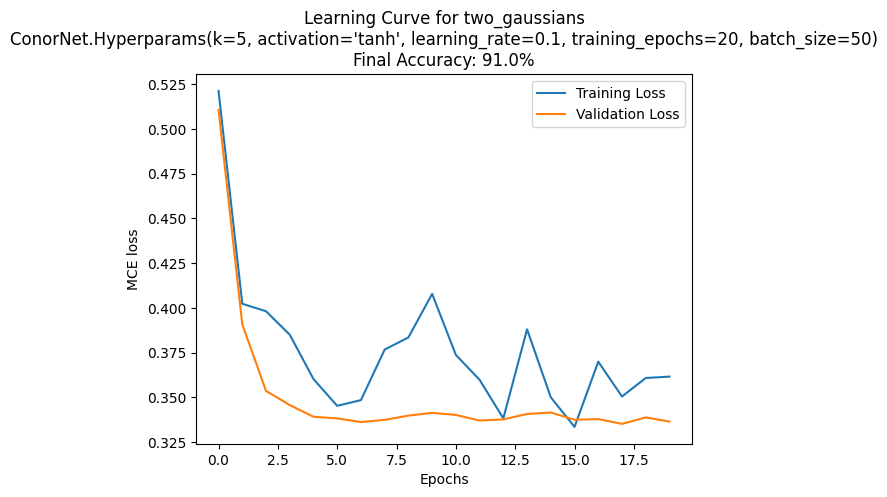

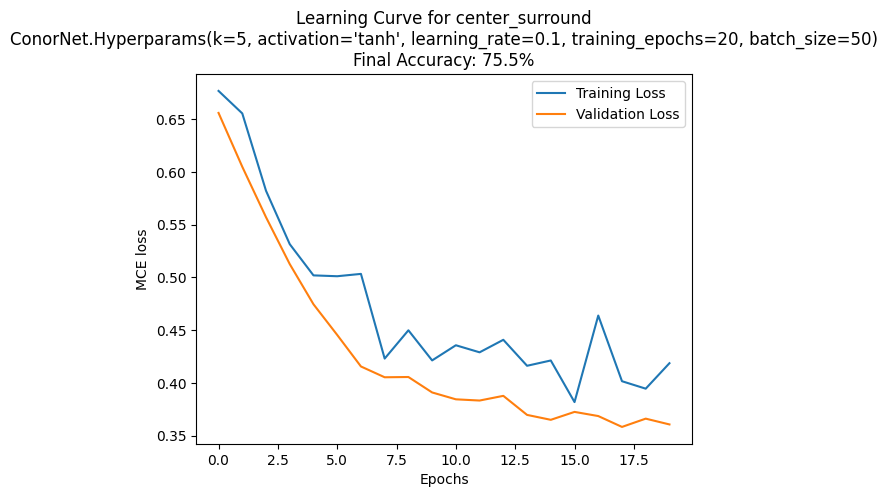

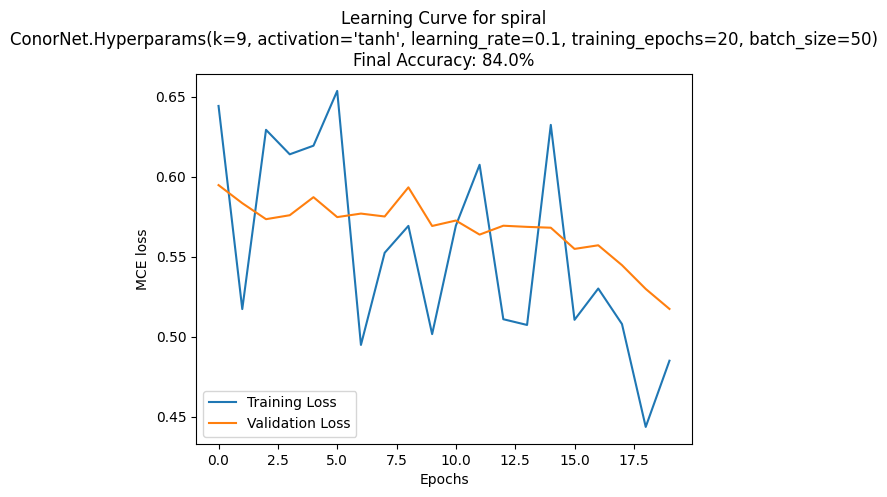

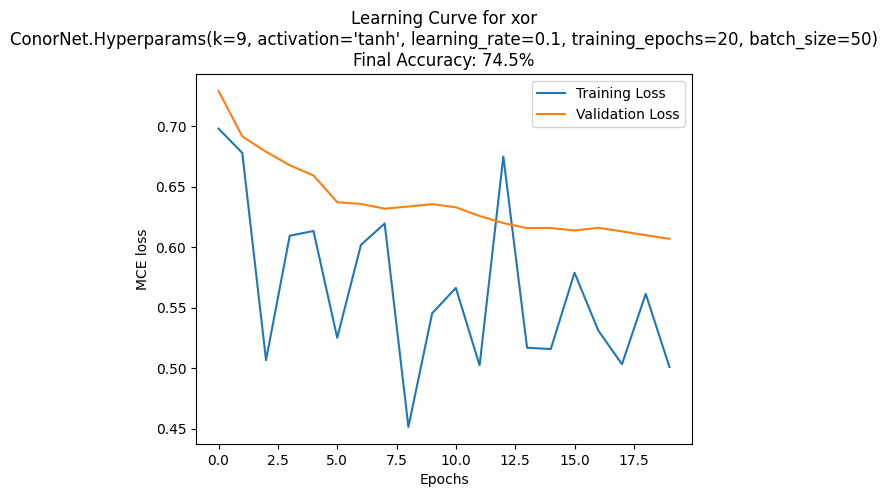

In [76]:
from dataclasses import field

# alright. time i make this a bit easier on myself. it's feeling like a "run" deserves its own
# class so i'm not dragging all these variables around

@dataclass
class RunResults:
    # keeping these for ease later
    model: ConorNet
    data: dict[str, HW1Dataset]

    # overall test accuracy
    test_accuracy: float = 0

    # both as a function of training epoch #
    training_loss: list[float] = field(default_factory=list)
    validation_loss: list[float] = field(default_factory=list)

class TrainAndTestRun:
    def __init__(self, hparams: ConorNet.Hyperparams, dset_name: str, use_softmax: bool = True) -> None:
        self.h = hparams
        self.model = ConorNet(hparams, use_softmax)
        self.dset = DSETS[dset_name]
        self.dset_name = dset_name
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.h.learning_rate)
        self.loss_fn = nn.CrossEntropyLoss()

        # bookkeeping from eval
        self.results: RunResults | None = None

    def eval(self) -> RunResults:
        print(f"Evaluating {self.dset_name} on {self.h}...")
        train_loader = DataLoader(self.dset["train"], batch_size=self.h.batch_size, shuffle=True)
        test_loader = DataLoader(self.dset["test"], batch_size=self.h.batch_size, shuffle=True)
        validation_loader = DataLoader(self.dset["valid"], batch_size=self.h.batch_size, shuffle=True)

        res = RunResults(self.model, self.dset)

        test_acc = 0
        for epoch in range(self.h.training_epochs):
            train_loss = train_loop(train_loader, self.model, self.loss_fn, 
                                    self.optimizer, self.h, debug_print=False)
            test_acc, test_loss = test_loop(test_loader, self.model, self.loss_fn, self.h, debug_print=False)
            valid_acc, valid_loss = test_loop(validation_loader, self.model, self.loss_fn, self.h, debug_print=False)

            res.training_loss.append(train_loss)
            res.validation_loss.append(valid_loss)
        
        res.test_accuracy = test_acc
        self.results = res
        return res

def eval_best_ks() -> None:
    # evaluate the model on test & train
    for dset_name, hparams in best_params_per_dataset.items():
        # rerun each so we collect the right data
        run = TrainAndTestRun(hparams, dset_name, True)
        res = run.eval()

        # plot learning curves
        fig = plt.figure()
        ax = fig.subplots()

        ax.plot(range(hparams.training_epochs), res.training_loss, label="Training Loss")
        ax.plot(range(hparams.training_epochs), res.validation_loss, label="Validation Loss")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("MCE loss")
        ax.set_title(f"Learning Curve for {dset_name}\n{hparams}\nFinal Accuracy: {100*res.test_accuracy:.1f}%")
        ax.legend()

eval_best_ks()